# Task 3 - Car Price Prediction

This notebook predicts used car selling prices from details such as brand, age, mileage, fuel type, seller type, and transmission.

In [1]:
import os
from io import BytesIO
from pathlib import Path
from zipfile import ZipFile

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')

## Load the dataset

In [2]:
data_dir = Path.cwd() / 'data'
if not data_dir.is_dir():
    data_dir = Path.cwd().parent / 'data'

candidate_files = [data_dir / 'car data.csv', data_dir / 'car_price.csv', data_dir / 'car_details.csv']
source = next((file for file in candidate_files if file.is_file()), None)

if source is not None:
    df = pd.read_csv(source)
else:
    dataset_url = 'https://www.kaggle.com/api/v1/datasets/download/nehalbirla/vehicle-dataset-from-cardekho'
    try:
        response = requests.get(dataset_url, timeout=30)
        response.raise_for_status()
        with ZipFile(BytesIO(response.content)) as archive:
            csv_name = next(name for name in archive.namelist() if name.lower().endswith('car data.csv'))
            with archive.open(csv_name) as csv_file:
                df = pd.read_csv(csv_file)
        source = f'{dataset_url} ({csv_name})'
    except (requests.RequestException, OSError, StopIteration) as error:
        raise FileNotFoundError(
            'Dataset not found locally and the online download failed. '
            'Add car data.csv to the data folder and run this cell again.'
        ) from error

print('Loaded from:', source)
df.head()

Loaded from: C:\Users\Angad\OIBSIP\OIBSIP_DataScience_task3\data\car data.csv


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isna().sum())
print('\nDuplicates:', df.duplicated().sum())

df.describe(include='all')

Shape: (301, 9)

Missing values:
car_name         0
year             0
selling_price    0
present_price    0
kms_driven       0
fuel_type        0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicates: 2


,car_name,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.644115,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000


## Clean and prepare fields

In [4]:
df = df.drop_duplicates().copy()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()
    if col not in ['car_name']:
        df[col] = df[col].str.title()

if 'year' in df.columns:
    df['car_age'] = pd.Timestamp.today().year - df['year']

if 'car_name' in df.columns:
    df['brand'] = df['car_name'].str.split().str[0].str.title()

df = df.dropna(subset=['selling_price'])
df.head()

C:\Users\Angad\AppData\Local\Temp\ipykernel_12816\1904961539.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,car_name,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner,car_age,brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,Ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,Sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,Ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,Wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,Swift


## Exploratory analysis

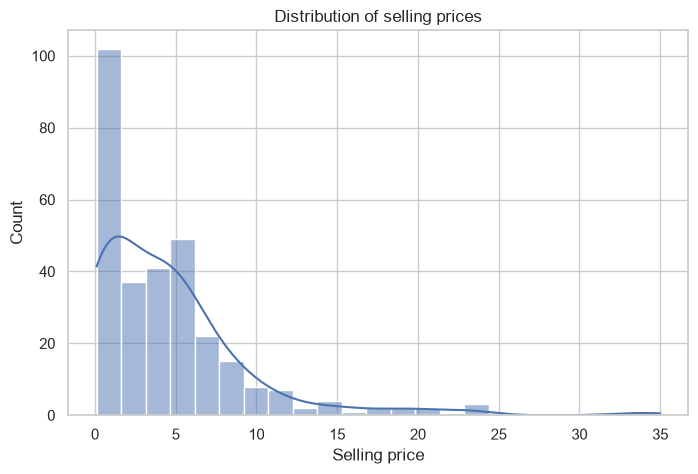

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df['selling_price'], kde=True)
plt.title('Distribution of selling prices')
plt.xlabel('Selling price')
plt.show()

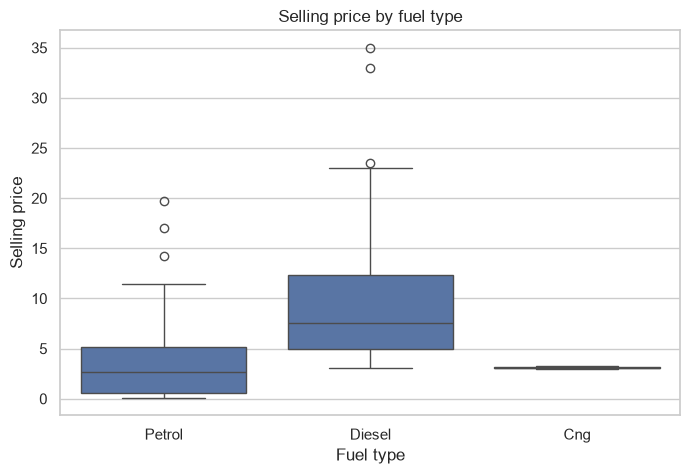

In [6]:
if 'fuel_type' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='fuel_type', y='selling_price')
    plt.title('Selling price by fuel type')
    plt.xlabel('Fuel type')
    plt.ylabel('Selling price')
    plt.show()

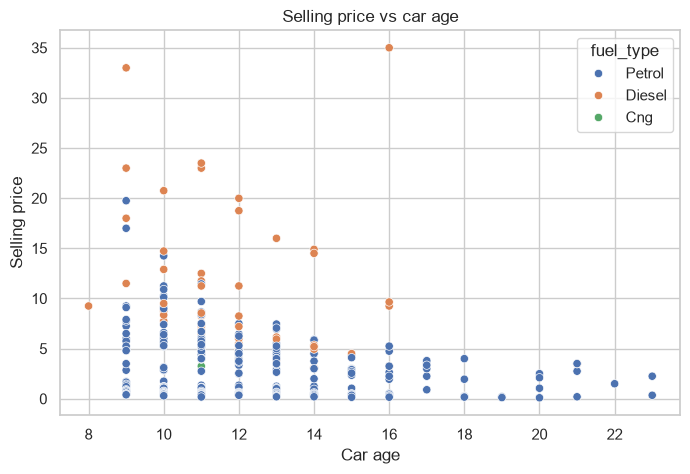

In [7]:
if 'car_age' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='car_age', y='selling_price', hue='fuel_type' if 'fuel_type' in df.columns else None)
    plt.title('Selling price vs car age')
    plt.xlabel('Car age')
    plt.ylabel('Selling price')
    plt.show()

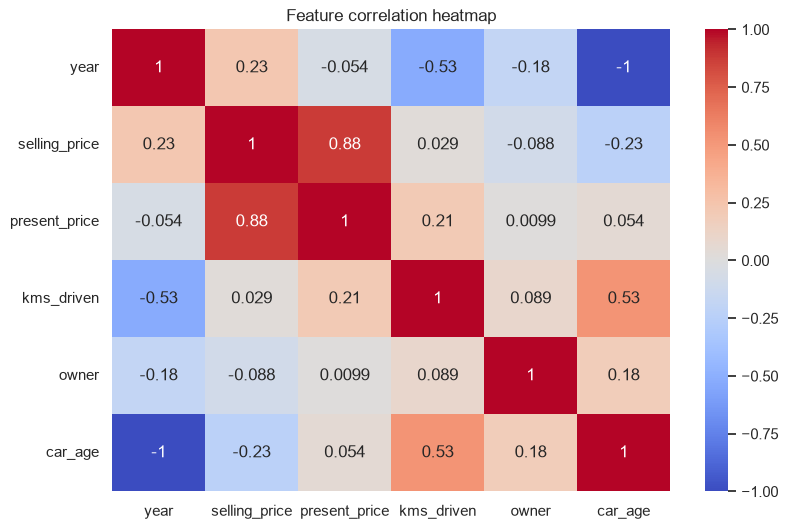

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(9, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature correlation heatmap')
plt.show()

Car age and present price are usually strong signals. Newer cars and cars with higher original prices tend to have higher selling prices.

## Model training

In [9]:
target = 'selling_price'
drop_cols = [target, 'car_name']
if 'year' in df.columns:
    drop_cols.append('year')

X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df[target]

categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numeric_cols)
])

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=150, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rows = []
fitted_models = {}
for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rows.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    })
    fitted_models[name] = pipe

results = pd.DataFrame(rows).sort_values('R2', ascending=False)
results

,Model,MAE,RMSE,R2
0,Linear Regression,1.348138,2.388979,0.778560
2,Gradient Boosting,1.097346,2.545123,0.748668
1,Random Forest,1.389149,3.370103,0.559327


In [10]:
best_name = results.iloc[0]['Model']
best_model = fitted_models[best_name]
print('Best model:', best_name)

model_step = best_model.named_steps['model']
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

if hasattr(model_step, 'feature_importances_'):
    importance = pd.DataFrame({
        'feature': feature_names,
        'importance': model_step.feature_importances_
    }).sort_values('importance', ascending=False).head(12)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=importance, x='importance', y='feature')
    plt.title(f'Top feature importances - {best_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()
else:
    print('The best model does not expose feature_importances_.')

Best model: Linear Regression
The best model does not expose feature_importances_.


## Conclusion

I selected the model with the strongest test-set R-squared score, while also checking that its error values stayed low. Tree-based models can work well here because used-car prices do not follow a perfectly linear pattern.